In [ ]:
# Install hypertools (run this first on Colab)
%pip install -q "hypertools[interactive]"

# Manipulating data with `hyp.manip`, and animating windows and trails

`hyp.manip` applies per-dataset manipulations -- `Smooth`, `Resample`, `ZScore`, `Normalize` -- and runs first in the library's canonical pipeline (`manip -> normalize -> reduce -> align -> cluster`). They run in native space: `Smooth` and `Resample` treat each dataset on its own, while `ZScore` and `Normalize` fit one shared set of statistics across a list. The same specs go into `hyp.plot(..., manip=)`. The second half of this notebook animates the manipulated data with a sliding window (`animate='window'`, sized by `focused=`) and with the three trail styles.

## Import packages and load the data

In [1]:
import numpy as np
import pandas as pd

import hypertools as hyp

%matplotlib inline
subjects = hyp.load('weights_sample')
subject = subjects[0]
[s.shape for s in subjects]

[(300, 100), (300, 100), (300, 100)]

## `Smooth`

`Smooth` is a Savitzky-Golay filter along the time axis (`mode='savgol'`; `kernel_width` must be odd, `order` is the polynomial degree). It returns a DataFrame with the same shape. Below, the raw and smoothed versions of one subject are drawn in the same space.

DataFrame (300, 100)


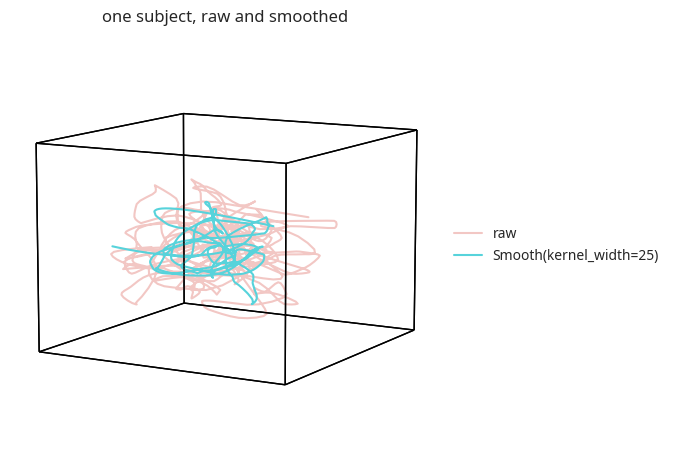

In [2]:
smoothed = hyp.manip(subject, model='Smooth', kernel_width=25)
print(type(smoothed).__name__, smoothed.shape)
fig = hyp.plot([subject, smoothed], names=['raw', 'Smooth(kernel_width=25)'], alpha=[0.35, 1.0],
               title='one subject, raw and smoothed')

## `Resample`

`Resample` interpolates each dataset to exactly `n_samples` rows (PCHIP along the time axis), which is how trajectories of different lengths are brought to a common length. `hyp.plot(..., resample=N)` is sugar for the same manipulator.

In [3]:
resampled = hyp.manip(subject, model='Resample', n_samples=100)
print(subject.shape, '->', resampled.shape)

(300, 100) -> (100, 100)


## `ZScore` and `Normalize`

`ZScore` gives every column zero mean and unit variance; `Normalize` rescales every column into `[min, max]` (`0` to `1` by default). On a list, both fit **one** set of statistics across all the datasets, so a column's mean is zero over the stacked rows, not within each dataset.

In [4]:
zscored = hyp.manip(subjects, model='ZScore')
normalized = hyp.manip(subject, model='Normalize')
stacked = pd.concat(zscored)
print('ZScore over the stack: mean', np.round(float(stacked.mean().mean()), 3), 'std', np.round(float(stacked.std().mean()), 3),
      '| within subject 1: mean', np.round(float(zscored[0].mean().mean()), 3))
print('Normalize: min', float(normalized.min().min()), 'max', float(normalized.max().max()))

ZScore over the stack: mean 0.0 std 1.0 | within subject 1: mean -0.0
Normalize: min 0.0 max 1.0


## Chaining manipulations

A list chains its elements into a `hyp.Pipeline` and runs it end to end; dict specs carry each step's keyword arguments. With `return_model=True` the fitted pipeline comes back, ready to `.transform` new data.

In [5]:
chain = [{'model': 'Smooth', 'kwargs': {'kernel_width': 25}},
         {'model': 'Resample', 'kwargs': {'n_samples': 150}},
         'ZScore']
manipulated, pipeline = hyp.manip(subjects, model=chain, return_model=True)
print([a.shape for a in manipulated])
pipeline

[(150, 100), (150, 100), (150, 100)]


,steps,"[('smooth', ...), ('resample', ...), ...]"
,input_hierarchy,None


## `manip=` inside `plot`

The same spec -- a name or the whole chain -- goes into `hyp.plot(..., manip=)`, where it runs before `normalize=`, `reduce=` and `align=`.

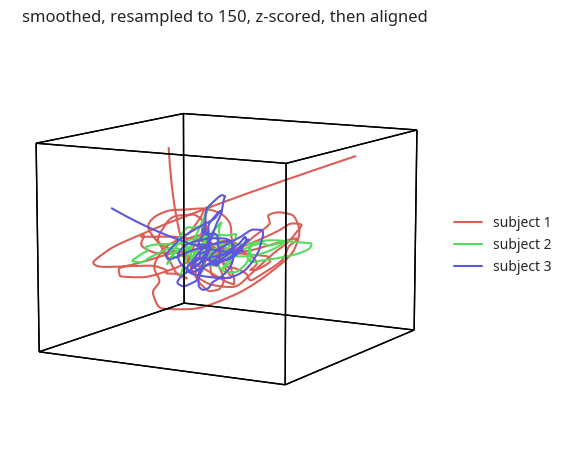

In [6]:
fig = hyp.plot(subjects, manip=chain, align='HyperAlign',
               names=['subject 1', 'subject 2', 'subject 3'],
               title='smoothed, resampled to 150, z-scored, then aligned')

## A sliding window: `animate='window'` with `focused=`

`animate='window'` shows only a moving window of each trajectory: what is inside the window is drawn opaque and everything else is hidden. `focused=` is the window's length in **seconds** of animation time (the same unit as `tail_duration`); it defaults to `tail_duration`'s value, so passing it explicitly is what decouples the two. The clip is saved next to this notebook as `manip.mp4`, and its middle frame is shown in place.

120 frames


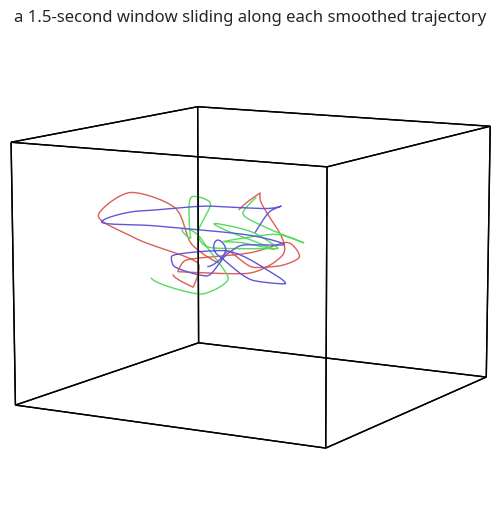

In [7]:
anim = hyp.plot(subjects, manip='Smooth', animate='window', focused=1.5,
                duration=8, frame_rate=15, save_path='manip.mp4',
                title='a 1.5-second window sliding along each smoothed trajectory', show=False)
print(f'{anim.n_frames} frames')
_ = anim.draw_frame(anim.n_frames // 2)
anim.figure

<video controls loop muted autoplay playsinline src="manip.mp4" title="A sliding window along three smoothed trajectories" style="max-width: 100%"></video>

[Download the clip](manip.mp4)

## Trails: `chemtrails`, `precog` and `bullettime`

With `animate=True` (or `'parallel'`/`'serial'`) each dataset can leave a low-opacity trail around its moving window: `chemtrails=True` draws the path already traversed, `precog=True` draws the path still to come, and `bullettime=True` draws both. Each accepts a per-dataset list, so the three styles can be mixed in one animation; `focused=` sets the opaque window's length here too. `animate='window'` is bullettime minus its trail, and `'spin'` and `'morph'` have no moving position for a trail to follow, so those modes ignore the trail flags with a warning. The frame below is a third of the way through.

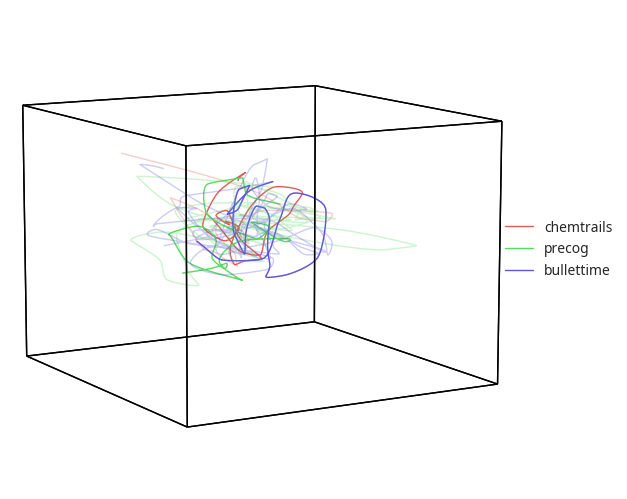

In [8]:
trails = hyp.plot(subjects, manip='Smooth', animate=True, focused=1.5,
                  chemtrails=[True, False, False], precog=[False, True, False], bullettime=[False, False, True],
                  names=['chemtrails', 'precog', 'bullettime'],
                  duration=8, frame_rate=15, show=False)
_ = trails.draw_frame(trails.n_frames // 3)
trails.figure